In [4]:
import py4hw

In [5]:

class FullAdder(py4hw.Logic):
    def __init__(self, parent, name, x, y, ci, s, co):
        super().__init__(parent, name)
        
        x = self.addIn('x', x)
        y = self.addIn('y', y)
        ci = self.addIn('ci', ci)
        s = self.addOut('s', s)
        co = self.addOut('co', co)
        
        w1 = self.wire('w1',1)
        w2 = self.wire('w2',1)
        w3 = self.wire('w3',1)
        
        py4hw.Xor2(self, 'g1', x, y, w1)
        py4hw.Xor2(self, 'g2', w1, ci, s)
        py4hw.And2(self, 'g3', w1, ci, w2)
        py4hw.And2(self, 'g4', x, y, w3)
        py4hw.Or2(self, 'g5', w2, w3, co)

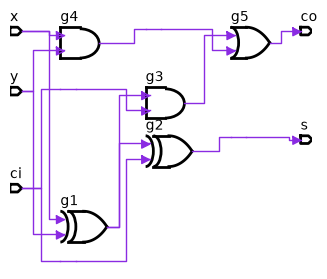

In [7]:
hw = py4hw.HWSystem()
x = hw.wire('a', 1)
y = hw.wire('b', 1)
ci = hw.wire('ci', 1)
co = hw.wire('co', 1)
s = hw.wire('s', 1)
fa = FullAdder(hw, 'fa', x,y,ci,s, co)
sch = py4hw.Schematic(fa)

sch.draw()

In [8]:
hw = py4hw.HWSystem()
x = hw.wire('a', 1)
y = hw.wire('b', 1)
ci = hw.wire('ci', 1)
co = hw.wire('co', 1)
s = hw.wire('s', 1)
py4hw.Sequence(hw, 'x', [0,1], x)
py4hw.Sequence(hw, 'y', [0,0,1,1], y)
py4hw.Sequence(hw, 'ci', [0, 0, 0, 0, 1, 1, 1, 1], ci)
fa = FullAdder(hw, 'fa', x,y,ci,s, co)
wvf = py4hw.Waveform(hw, 'wvf', [x,y,ci,s,co])
hw.getSimulator().clk(4*4)
wvf.draw_wavedrom()